# Building a Reflection Agent with LangGraph

## What is Reflection?
Reflection is a prompting strategy aimed at enhancing the quality and accuracy of outputs generated by AI agents. It involves getting the agent to **pause, review, and critique** its own outputs before finalizing them. This iterative process helps in reducing errors and improving performance over time.

For example, when an AI model generates code, it typically outputs the result instantly. However, just like human programmers, code needs to be tested and refined. Reflection ensures that the AI agent **evaluates the generated code, identifies potential errors, and iterates** to fix them. This mimics how developers write, test, debug, and optimize their work, resulting in more reliable outputs.

A simple analogy is comparing it to having two systems:
- **System 1** – Reactive and instinctive (quick initial responses).
- **System 2** – Reflective and deliberate (carefully reviewing and refining outputs).

Reflection agents encourage AI to function more like **System 2**, iterating over their work until the desired quality is achieved.


## Building an Optimized LinkedIn Post Generator with a Reflection Agent

### Actual flow
- Generate a post using LLM
- Using an llm, check if post is matching given criteria. If yes, then return else reflect on post.
- Reflect on post, by giving feedback and improvements(if there is any) using another llm
- Then generate post again by passing previously generated post and improvements suggestion.
- Using an llm, check if post is matching given criteria. If yes, then return else reflect on post.
- Finally, return response

### Our flow
- Generate a post using LLM
- Check if messages list is greater than 6, then return response else reflect on post.
- Reflect on post, by giving feedback and improvements(if there is any) using another llm
- Then generate post again by passing previously generated post and improvements suggestion.
- Check if messages list is greater than 6, then return response else reflect on post.
- Finally, return response

### Another Flow Could be
- Generate a post using LLM
- Evaluate post, by giving feedback and improvements(if there is any) using another llm
- If improvements are required in post, then generate post again by passing previously generated post and improvements suggestion
- Finally, return response

In [27]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from IPython.display import Image, display

In [11]:
llm = ChatOpenAI(model='gpt-4.1-nano')

### Generation Prompt for Posts

In [3]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

### Creating the Chain for LinkedIn Post Generation

In [13]:
generate_chain = generation_prompt | llm

In [ ]:
generate_chain.invoke({"messages": ["I have completed langgraph course from coursera"]})

AIMessage(content='🎉 Exciting News! 🎉\n\nI am thrilled to share that I have successfully completed the **LangGraph Course** on Coursera! 🚀\n\nThis journey has deepened my understanding of language processing and graph-based algorithms, equipping me with valuable skills to tackle complex linguistic challenges. 📚🌐\n\nA big thank you to the instructors and fellow learners who made this experience enriching and inspiring. Looking forward to applying these insights to my projects and continuing my learning journey!\n\n#LifelongLearning #Coursera #LanguageProcessing #GraphAlgorithms #ProfessionalGrowth #NeverStopLearning', response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 83, 'total_tokens': 201, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp

In [ ]:
generate_chain.invoke({"messages": [HumanMessage("I have completed langgraph course from coursera")]})

AIMessage(content='🎉 Exciting News! 🎉\n\nI’m thrilled to share that I’ve just completed the LangGraph course on Coursera! 🚀\n\nThis experience has deepened my understanding of language processing and graph-based models, equipping me with new skills to tackle complex challenges in AI and NLP. \n\nA big thank you to the instructors and fellow learners for the insightful discussions and support along the way. 🙏\n\nLooking forward to applying these new insights and continuing my learning journey. Let’s connect and explore opportunities in this exciting field! 💡\n\n#LifelongLearning #AI #NLP #Coursera #ProfessionalDevelopment #LanguageProcessing', response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 83, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14',

### Reflection Prompt for LinkedIn Post Critique

In [ ]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

### Creating the Reflect Chain

In [14]:
reflect_chain = reflection_prompt | llm

### Defining the Agent State for Reflection Agent

When building a conversational workflow from scratch, the **state** represents the evolving context of the conversation or task. It tracks the interactions between the user and the AI, growing dynamically as new messages are added. 

If we were to define the state manually, it would look like this:

In [ ]:
#### Manual State Definition

# If we use below code for state management, then we need to use StateGraph instead of MessageGraph

from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage
from langgraph.graph.message import add_messages

# Define State with TypedDict
class AgentState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage | SystemMessage], "add_messages"]
    # messages: Annotated[List[HumanMessage | AIMessage | SystemMessage], add_messages] # Same as above
    # messages: Annotated[Sequence[BaseMessage], add_messages] # Same as above
    # messages: Annotated[list, add_messages] # simple version of above

# In this setup:  
# - HumanMessage: Represents user inputs or prompts.  
# - AIMessage: Represents AI-generated responses.  
# - SystemMessage: Represents system-level instructions, such as refinement feedback or evaluation criteria.  
# - add_messages: Ensures new messages are appended to the list, preserving the context needed for iterative interactions.

`While this approach is flexible, it requires manual management of the state, including creating workflows and maintaining the message list.`

### LangGraph's MessageGraph

Instead of manually defining and managing the state, **LangGraph** offers a **prebuilt solution** called `MessageGraph`. It abstracts the complexity of state management, making it easy to create and work with conversational workflows.

In [66]:
# Initialize a predefined MessageGraph
graph = MessageGraph()

### Defining the Generation and Reflection Node

In [18]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [19]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

The output is wrapped in a `HumanMessage` instead of `AIMessage` because the reflection process is a form of feedback or critique given to the **generation agent**, and the feedback is intended to be treated as if it is coming from the user. This is important for the iterative process where the AI generates content and then receives human-like feedback to improve the output. In the context of this workflow, we treat the feedback as if a human is guiding the reflection agent to enhance its output.

- **HumanMessage** here is not used to represent user input directly but rather to provide feedback (as if from a human perspective). This feedback is passed back into the system, enabling the generation agent to revise its content. 
- It effectively gives the reflection node the authority to "speak" to the generation node, but in the context of providing critique and recommendations for refinement.


### Adding Nodes and Edges to the Graph

In [ ]:
def should_continue(state: List[BaseMessage]):
    print('----- STATE -----')
    print(state)
    print('----- STATE LENGTH -----')
    print(len(state))
    print("----------------------------------------------------------------------")
    # This logic could be replaced with an llm to evaluate post content
    if len(state) >=4:
        return "END"
    return "reflect"

In [68]:
graph.add_node("generate", generation_node) # Add generate Node to graph
graph.add_node("reflect", reflection_node) # Add reflection Node to graph

graph.set_entry_point("generate")
graph.add_conditional_edges("generate", should_continue, {"reflect": "reflect", "END": END})
graph.add_edge("reflect", "generate")


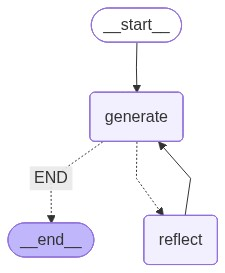

In [69]:
workflow = graph.compile()
display(Image(workflow.get_graph().draw_mermaid_png()))

### Execute workflow

In [70]:
### Both of below inputs, will work fine on workflow invoke
# inputs = HumanMessage(content="""Write a linkedin post on completing langgraph course from coursera""")
inputs = [HumanMessage(content="""Write a linkedin post on completing langgraph course from coursera""")]

In [71]:
response = workflow.invoke(inputs)

----- STATE -----
[HumanMessage(content='Write a linkedin post on completing langgraph course from coursera', id='69c53141-9bd5-4d27-96e1-9e52b2fd9b90'), AIMessage(content='🚀 Excited to Share a Milestone! 🚀\n\nI’ve just completed the LangGraph course on Coursera, and I couldn’t be more thrilled! 🎉\n\nThis course has been an incredible journey into the world of language processing and graph-based models. I’ve gained valuable insights into how language graphs can enhance understanding and improve natural language processing tasks. 🧠💬\n\nA huge thank you to the instructors and the Coursera community for the support and engaging content. I’m now eager to apply these new skills to real-world challenges and continue my learning journey in AI and NLP.\n\n#LifelongLearning #Coursera #NLP #LanguageProcessing #AI #ProfessionalDevelopment #LearningJourney', id='a2ced1de-f134-4dbb-8f2c-1c0359c40c1b')]
----- STATE LENGTH -----
2
----------------------------------------------------------------------

In [82]:
print("User Query: --> ", response[0].content)
print("Generator Node: --> ", response[1].content, end='\n\n\n')
print("Reflect Node: --> ", response[2].content, end='\n\n\n')
print("Generator Node - Final Response: --> ", response[3].content) 


User Query: -->  Write a linkedin post on completing langgraph course from coursera
Generator Node: -->  🚀 Excited to Share a Milestone! 🚀

I’ve just completed the LangGraph course on Coursera, and I couldn’t be more thrilled! 🎉

This course has been an incredible journey into the world of language processing and graph-based models. I’ve gained valuable insights into how language graphs can enhance understanding and improve natural language processing tasks. 🧠💬

A huge thank you to the instructors and the Coursera community for the support and engaging content. I’m now eager to apply these new skills to real-world challenges and continue my learning journey in AI and NLP.

#LifelongLearning #Coursera #NLP #LanguageProcessing #AI #ProfessionalDevelopment #LearningJourney


Reflect Node: -->  This is a solid starting point for a LinkedIn post celebrating a course completion. Here’s a detailed critique based on the guidelines:

**Strengths:**
- **Enthusiastic tone:** The post conveys exci